In [1]:
# Run once before other notebooks
import os
from pathlib import Path

EXPECTED_ROOT = "Common-voice-asr"
cwd = Path(os.getcwd())

if cwd.name != EXPECTED_ROOT:
    os.chdir(Path("..").resolve())
print("CWD:", os.getcwd())

!pip install -r requirements.txt

CWD: /home/jupyter/common-voice-asr/Common-voice-asr


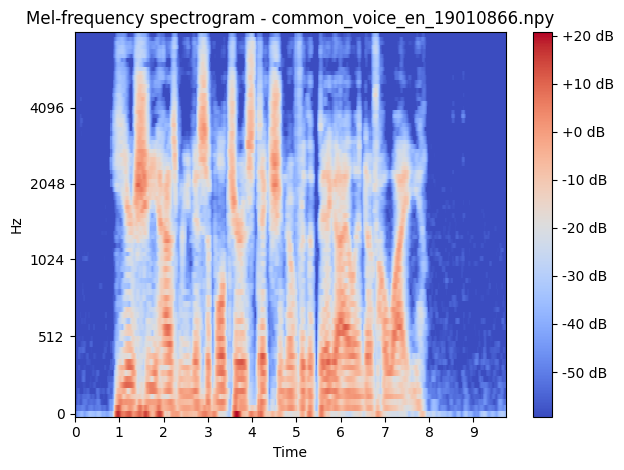

In [2]:
# Display Preprocessed Spectogram
import numpy as np
import matplotlib.pyplot as plt
import torch
import librosa.display
from dotenv import load_dotenv

load_dotenv()
BASE_DIR = Path(os.getenv("BASE_DIR", Path.cwd()))
PROCESSED_DIR = os.path.join(BASE_DIR, "corpus_data/processed/best_train_cv")
npy_file = [file for file in os.listdir(PROCESSED_DIR) if file.endswith('.npy')][0]

spect_path = os.path.join(PROCESSED_DIR, npy_file)
S_dB = np.load(spect_path)

fig, ax = plt.subplots()
img = librosa.display.specshow(S_dB, x_axis='time', y_axis='mel', sr=22050, fmax=8000, ax=ax)
fig.colorbar(img, ax=ax, format='%+2.0f dB')
ax.set(title=f"Mel-frequency spectrogram - {npy_file}")
plt.tight_layout()
plt.show()

DirectoryDeletedError: Directory /home/jupyter/common-voice-asr/Common-voice-asr/runs/best_model_b has been permanently deleted

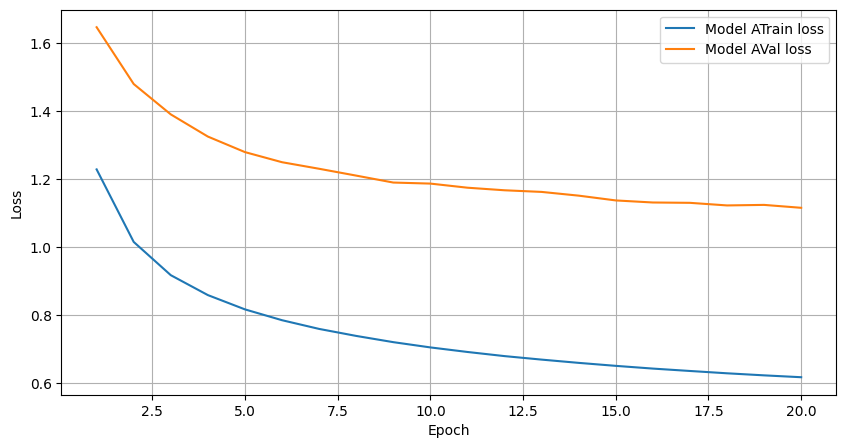

In [3]:
# Display Loss curves for full training on best model hyperparameters
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

def plot_loss_curves(log_dir, label_pref=""):
    event_acc = EventAccumulator(log_dir)
    event_acc.Reload()

    train_losses = event_acc.Scalars("Loss/train")
    val_losses = event_acc.Scalars("Loss/val")

    train_steps = [x.step for x in train_losses]
    train_vals = [x.value for x in train_losses]
    val_steps = [x.step for x in val_losses]
    val_vals = [x.value for x in val_losses]

    plt.plot(train_steps, train_vals, label=f"{label_pref}Train loss")
    plt.plot(val_steps, val_vals, label=f"{label_pref}Val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

mod_a_dir = os.path.join(BASE_DIR, "neural_networks/runs/best_model_a")
mod_b_dir = os.path.join(BASE_DIR, "runs/best_model_b")
plt.figure(figsize=(10,5))
plot_loss_curves(mod_a_dir, "Model A")
plot_loss_curves(mod_b_dir, "Model B")
plt.title("Training vs Validation Loss")
plt.show()

In [ ]:
# Compare WER over time for Model A vs Model B best hyperparameter runs

def plot_wer_curves(log_dir, label_pref=""):
    event_acc = EventAccumulator(log_dir)
    event_acc.Reload()

    train_wer = event_acc.Scalars("WER/train")
    val_wer = event_acc.Scalars("WER/val")

    train_steps = [x.step for x in train_wer]
    train_vals = [x.value for x in train_wer]
    val_steps = [x.step for x in val_wer]
    val_vals = [x.value for x in val_wer]

    plt.plot(train_steps, train_vals, label=f"{label_pref} Train WER")
    plt.plot(val_steps, val_vals, label=f"{label_pref} Val WER")
    plt.xlabel("Epoch")
    plt.ylabel("WER")
    plt.title("Training vs Validation WER")
    plt.legend()
    plt.grid(True)

mod_a_dir = os.path.join(BASE_DIR, "neural_networks/runs/best_model_a")
mod_b_dir = os.path.join(BASE_DIR, "runs/best_model_b")
plt.figure(figsize=(10,5))
plot_wer_curves(mod_a_dir, "Model A")
plot_wer_curves(mod_b_dir, "Model B")
plt.title("Training vs Validation WER")
plt.show()

In [ ]:
# Demo of a dummy run, step by step

In [ ]:
# Generating mel spectogram from audio
import pandas as pd
import librosa.display
from argparse import Namespace
from preprocess import preprocess

best_sr = 22050
best_nfft = 2048
best_hop = 256
best_nmels = 80

raw_audio_dir = BASE_DIR / "corpus_data/raw/train_cv"
demo_audio = sorted([f for f in raw_audio_dir.glob("*.mp3")])[:10]
demo_spects = os.path.join(BASE_DIR, f"corpus_data/processed/demos")

manifest_path = os.path.join(BASE_DIR, "corpus_data/cleaned_train.csv")
df = pd.read_csv(manifest_path)
demo_filenames = [f.name for f in demo_audio]
filtered_df = df[df["filename"].isin(demo_filenames)]

preprocess(raw_audio_dir, demo_spects, best_sr, best_nfft, best_hop, best_nmels, demo_filenames)

demo_list = os.listdir(demo_spects)
npy_file = demo_list[0]
audio_stem = Path(npy_file).stem + ".mp3"
row = filtered_df[filtered_df["filename"] == audio_stem]
    
transcript = row.iloc[0]["transcript"]
duration = row.iloc[0]["duration"]
print(f"Transcript: {transcript}")
print(f"Duration: {duration:.2f} sec")
    
# show mel spectogram
spect_path = os.path.join(demo_spects, npy_file)
S_dB = np.load(spect_path)
fig, ax = plt.subplots()
img = librosa.display.specshow(S_dB, x_axis='time', y_axis='mel', sr=22050, fmax=8000, ax=ax)
fig.colorbar(img, ax=ax, format='%+2.0f dB')
ax.set(title=f"Mel-frequency spectrogram - {npy_file}")
plt.tight_layout()
plt.show()

In [ ]:
# MODEL A: Generate the dataset & print out values (basically main function before training is called)
import string
import pandas as pd
from torch.utils.data import random_split, DataLoader
from neural_networks.datasets import CTC_MiniCVDataset, ctc_rnn_collate_fn
from neural_networks.model_A.rnn_encoder import CTC_RNNEncoder

tokens = ['<blank>', '|'] + list(string.ascii_uppercase) + [' ', "'", '-']
num_classes = len(tokens)

manifest_path = os.path.join(BASE_DIR, 'corpus_data/demo_manifest.csv')
if not os.path.exists(manifest_path):
    filtered_df.to_csv(manifest_path, index=False)

dataset = CTC_MiniCVDataset(manifest_path, demo_spects)

# splitting the data into validation & 
total_len = len(dataset)
train_len = int(0.8 * total_len)
val_len = total_len - train_len
train_set, val_set = random_split(dataset, [train_len, val_len])

model = CTC_RNNEncoder(num_classes=num_classes, hidden_size=128)
collate_fn = ctc_rnn_collate_fn
    
train_loader = DataLoader(train_set, batch_size=2, collate_fn=collate_fn, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=2, collate_fn=collate_fn, num_workers=4, pin_memory=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

for batch_idx, (spects, targets, input_lengths, target_lengths, empty_batch) in enumerate(train_loader):
    spects, targets = spects.to(device), targets.to(device)
    input_lengths, target_lengths = input_lengths.to(device), target_lengths.to(device)
    outputs = model(spects)
    print("TRAIN")
    print("Spects: ", spects)
    print("Targets: ", targets)
    print("Input lengths: ", input_lengths)
    print("Target lengths: ", target_lengths)
    print("Spects shape: ", spects.shape)
    print("Outputs shape: ", outputs.shape)
for batch_idx, (spects, targets, input_lengths, target_lengths, empty_batch) in enumerate(val_loader):
    spects, targets = spects.to(device), targets.to(device)
    input_lengths, target_lengths = input_lengths.to(device), target_lengths.to(device)
    outputs = model(spects)
    print("VAL")
    print("Spects: ", spects)
    print("Targets: ", targets)
    print("Input lengths: ", input_lengths)
    print("Target lengths: ", target_lengths)
    print("Spects shape: ", spects.shape)
    print("Outputs shape: ", outputs.shape)

In [ ]:
# MODEL A: Go through a singular training loop with print statements
# Goes through the model & decodes model outputs
import torchaudio
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from neural_networks.greedy_ctc_decoder import GreedyCTCDecoder
from neural_networks.beam_search_decoder import beam_search_decoder

criterion = nn.CTCLoss(blank=0, zero_infinity=True)
optimizer = optim.AdamW(model.parameters(), lr=0.001)

def mini_train(decoder, print_count):
    if isinstance(decoder, GreedyCTCDecoder) and (print_count==0):
        print("GREEDY DECODER")
    elif print_count == 0:
        print("BEAM SEARCH DECODER")
    model.train()
    count = 0
    total_wer = 0.0
    scaler = torch.amp.GradScaler('cuda')

    for batch_idx, (spects, targets, input_lengths, target_lengths, empty_batch) in enumerate(train_loader):
        if empty_batch: 
            continue
        spects, targets = spects.to(device), targets.to(device)
        input_lengths, target_lengths = input_lengths.to(device), target_lengths.to(device)

        optimizer.zero_grad()
        with torch.amp.autocast('cuda', enabled=False): 
            outputs = model(spects) # Expected output shape: (Batch, Time, Classes)

            blank_bias = 1.5 
            outputs[:, :, 0] += blank_bias
            outputs = outputs.float()
            log_probs = F.log_softmax(outputs, dim=2)
            print("Log probabilities: ", log_probs.shape)

            # Permute for CTCLoss: (Time, Batch, Classes)
            log_probs_for_loss = log_probs.permute(1, 0, 2)
            print("Log probabilities for CTC Loss: ", log_probs_for_loss.shape)

            T_max = outputs.size(1)
            input_lengths = input_lengths.clamp(max=T_max)

            loss = criterion(log_probs_for_loss, targets, input_lengths, target_lengths)
            print(f"Loss: {loss}")

        # Backpropagation
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        scaler.step(optimizer)
        scaler.update()

        # Decode for WER calculation
        print("Input to decoder: ", outputs.shape)
        hypotheses = decoder(outputs)

        # Get References
        references = []
        start = 0
        for t_len in target_lengths:
            end = start + t_len.item()
            indices = targets[start:end]
            ref = "".join([tokens[i] for i in indices]).replace("|", " ").strip().split()
            references.append(ref)
            start = end

        # Get WER
        for ref, hyp in zip(references, hypotheses):
            if batch_idx == 0:
                print(f"Reference: {ref}")
                print(f"Hypotheses: {hyp}")
            total_wer += min(torchaudio.functional.edit_distance(ref, hyp) / max(len(ref), 1), 1)
            count += 1

epochs = 5
greedy_count = 0
beam_count = 0
for epoch in range(epochs):
    mini_train(GreedyCTCDecoder(tokens), greedy_count)
    greedy_count += 1
for epoch in range(epochs):
    mini_train(beam_search_decoder(tokens, lm_weight=2, word_score=0.5, beam_size=32), beam_count)
    beam_count += 1

In [ ]:
# MODEL A: Full run on demo dataset - Model A Greedy
from neural_networks.modeling.train import main as train
args = Namespace(model_type="rnn", logdir="runs/demo_a", check_data=False, full_mini=False, corpus=False, greedy=False,
                 epochs=20, lr=1e-4, batch_size=2, hidden_dim=128, test_sweep=True, lm_weight=2, word_score=-0.5, sample_size=100,
                 d_model=256, nhead=2, dim_feedforward=512, nlayers=2, lstm_hidden=128, lstm_layers=1, dropout=0.3, 
                 sample_spect_folder=None, debug_sample=False, conv_layer=False, beam_width=32, best=False, demo=True)
train(args)

In [ ]:
# MODEL B: Generate the dataset & print out values
from neural_networks.datasets import transformer_collate_fn
from neural_networks.model_B.hybrid_transformer import HybridTransformer

N_MELS = 80

model = HybridTransformer(input_dim=N_MELS, vocab_size=num_classes)
collate_fn = transformer_collate_fn
    
train_loader = DataLoader(train_set, batch_size=8, collate_fn=collate_fn, shuffle=True, num_workers=4, pin_memory=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

for batch_idx, (spects, targets, input_lengths, target_lengths, empty_batch) in enumerate(train_loader):
    spects, targets = spects.to(device), targets.to(device)
    input_lengths, target_lengths = input_lengths.to(device), target_lengths.to(device)
    outputs = model(spects)
    print("Spects: ", spects)
    print("Targets: ", targets)
    print("Input lengths: ", input_lengths)
    print("Target lengths: ", target_lengths)
    print("Spects shape: ", spects.shape)
    print("Outputs shape: ", outputs.shape)
    
for batch_idx, (spects, targets, input_lengths, target_lengths, empty_batch) in enumerate(val_loader):
    spects, targets = spects.to(device), targets.to(device)
    input_lengths, target_lengths = input_lengths.to(device), target_lengths.to(device)
    outputs = model(spects)
    print("[VAL]")
    print("Spects: ", spects)
    print("Targets: ", targets)
    print("Input lengths: ", input_lengths)
    print("Target lengths: ", target_lengths)
    print("Spects shape: ", spects.shape)
    print("Outputs shape: ", outputs.shape)

In [ ]:
# MODEL B: Go through a singular training loop with print statements
# using the same function from Model A since the operations are the same, but now using the Hybrid Transformer model 
greedy_count = 0
beam_count = 0

for epoch in range(epochs):
    mini_train(GreedyCTCDecoder(tokens), greedy_count)
    greedy_count += 1
for epoch in range(epochs):
    mini_train(beam_search_decoder(tokens, lm_weight=2, word_score=0.5, beam_size=32), beam_count)
    beam_count += 1

In [ ]:
# MODEL B: Full run on demo dataset - Model B Greedy
args = Namespace(model_type="rnn", logdir="runs/demo_b", check_data=False, full_mini=False, corpus=False, greedy=False,
                 epochs=20, lr=1e-3, batch_size=2, hidden_dim=128, test_sweep=True, lm_weight=3.23, word_score=-0.26, sample_size=100,
                 d_model=256, nhead=2, dim_feedforward=512, nlayers=2, lstm_hidden=128, lstm_layers=1, dropout=0.3, 
                 sample_spect_folder=None, debug_sample=False, conv_layer=False, beam_width=4, best=False, demo=True)
train(args)

In [ ]:
# Loss over time for RNN & Transformer demo runs

mod_a_demo = os.path.join(BASE_DIR, "runs/demo_a")
mod_b_dir = os.path.join(BASE_DIR, "runs/demo_b")
plt.figure(figsize=(10,5))
plot_loss_curves(mod_a_dir, "Model A Demos")
plot_loss_curves(mod_b_dir, "Model B Demos")
plt.title("Training vs Validation Loss")
plt.show()

In [ ]:
# Compare WER over time for RNN & Transformer demo runs
mod_a_demo = os.path.join(BASE_DIR, "runs/demo_a")
mod_b_dir = os.path.join(BASE_DIR, "runs/demo_b")
plt.figure(figsize=(10,5))
plot_wer_curves(mod_a_dir, "Model A Demos")
plot_wer_curves(mod_b_dir, "Model B Demos")
plt.title("Training vs Validation WER")
plt.show()